In [1]:
import pandas as pd

df = pd.read_csv("books_cleaned.csv")

df.head()

,title,price,rating,availability,url,price_clean,rating_numeric,price_category,rating_category
0,A Light in the Attic,Â£51.77,Three,in stock,a-light-in-the-attic_1000/index.html,51.77,3,High,Average
1,Tipping the Velvet,Â£53.74,One,in stock,tipping-the-velvet_999/index.html,53.74,1,High,Low Rated
2,Soumission,Â£50.10,One,in stock,soumission_998/index.html,50.10,1,High,Low Rated
3,Sharp Objects,Â£47.82,Four,in stock,sharp-objects_997/index.html,47.82,4,High,Highly Rated
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,in stock,sapiens-a-brief-history-of-humankind_996/index...,54.23,5,High,Highly Rated


In [2]:
X = df[["price_clean", "rating_numeric"]]

X.head()

,price_clean,rating_numeric
0,51.77,3
1,53.74,1
2,50.10,1
3,47.82,4
4,54.23,5


In [3]:
print(X.shape)

(1000, 2)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
print(X_scaled[:5])

[[ 1.15652834  0.05368662]
 [ 1.29296    -1.34077111]
 [ 1.04087309 -1.34077111]
 [ 0.88297249  0.75091549]
 [ 1.32689477  1.44814436]]


In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

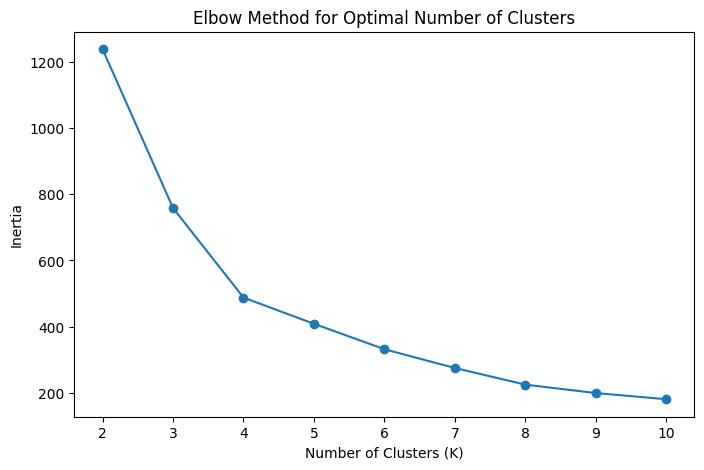

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.363
K = 3, Silhouette Score = 0.402
K = 4, Silhouette Score = 0.429
K = 5, Silhouette Score = 0.412
K = 6, Silhouette Score = 0.401
K = 7, Silhouette Score = 0.419
K = 8, Silhouette Score = 0.436
K = 9, Silhouette Score = 0.424
K = 10, Silhouette Score = 0.425


In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

In [11]:
print(df["cluster"].value_counts().sort_index())

cluster
0    308
1    225
2    197
3    270
Name: count, dtype: int64


In [12]:
cluster_summary = df.groupby("cluster").agg(
    book_count=("title", "count"),
    average_price=("price_clean", "mean"),
    average_rating=("rating_numeric", "mean")
)

cluster_summary = cluster_summary.round(2)

cluster_summary

,book_count,average_price,average_rating
cluster,,,
0,308,47.54,4.05
1,225,45.81,1.48
2,197,21.97,1.45
3,270,21.46,3.92


In [13]:
from sklearn.metrics import silhouette_score

final_score = silhouette_score(
    X_scaled,
    df["cluster"]
)

print("Final Silhouette Score:", round(final_score, 3))

Final Silhouette Score: 0.429


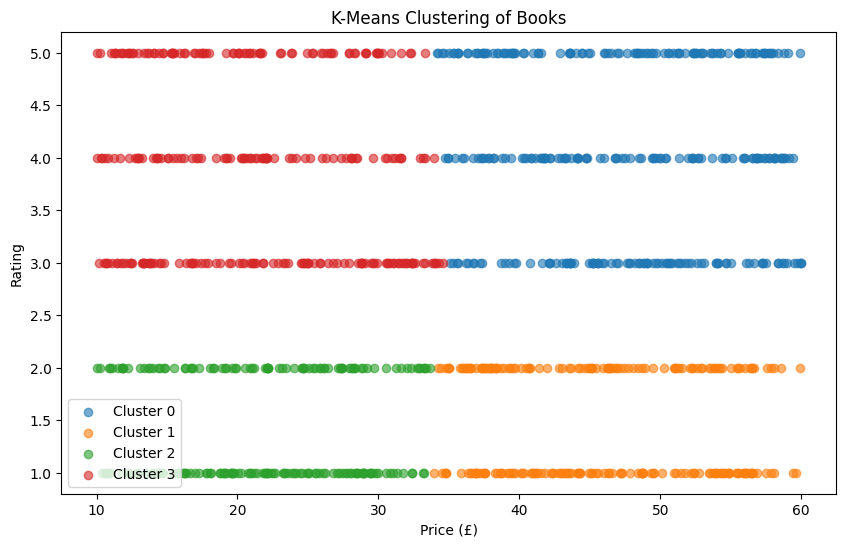

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(df["cluster"].unique()):
    
    cluster_data = df[df["cluster"] == cluster]
    
    plt.scatter(
        cluster_data["price_clean"],
        cluster_data["rating_numeric"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.title("K-Means Clustering of Books")
plt.xlabel("Price (£)")
plt.ylabel("Rating")
plt.legend()
plt.show()

In [15]:
cluster_summary = df.groupby("cluster").agg(
    book_count=("title", "count"),
    min_price=("price_clean", "min"),
    max_price=("price_clean", "max"),
    average_price=("price_clean", "mean"),
    average_rating=("rating_numeric", "mean"),
    min_rating=("rating_numeric", "min"),
    max_rating=("rating_numeric", "max")
).round(2)

cluster_summary

,book_count,min_price,max_price,average_price,average_rating,min_rating,max_rating
cluster,,,,,,,
0,308,34.13,59.99,47.54,4.05,3,5
1,225,33.97,59.95,45.81,1.48,1,2
2,197,10.02,33.63,21.97,1.45,1,2
3,270,10.00,34.56,21.46,3.92,3,5


In [16]:
print(df["cluster"].value_counts().sort_index())

cluster
0    308
1    225
2    197
3    270
Name: count, dtype: int64


In [17]:
cluster_names = {
    0: "Premium Highly-Rated",
    1: "Premium Low-Rated",
    2: "Budget Low-Rated",
    3: "Budget Highly-Rated"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

In [18]:
df[[
    "title",
    "price_clean",
    "rating_numeric",
    "cluster",
    "cluster_name"
]].head(20)

,title,price_clean,rating_numeric,cluster,cluster_name
0,A Light in the Attic,51.77,3,0,Premium Highly-Rated
1,Tipping the Velvet,53.74,1,1,Premium Low-Rated
2,Soumission,50.10,1,1,Premium Low-Rated
3,Sharp Objects,47.82,4,0,Premium Highly-Rated
4,Sapiens: A Brief History of Humankind,54.23,5,0,Premium Highly-Rated
5,The Requiem Red,22.65,1,2,Budget Low-Rated
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,3,Budget Highly-Rated
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,3,Budget Highly-Rated
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,3,Budget Highly-Rated
9,The Black Maria,52.15,1,1,Premium Low-Rated


In [19]:
final_cluster_summary = df.groupby("cluster_name").agg(
    book_count=("title", "count"),
    average_price=("price_clean", "mean"),
    average_rating=("rating_numeric", "mean")
).round(2)

final_cluster_summary

,book_count,average_price,average_rating
cluster_name,,,
Budget Highly-Rated,270,21.46,3.92
Budget Low-Rated,197,21.97,1.45
Premium Highly-Rated,308,47.54,4.05
Premium Low-Rated,225,45.81,1.48


In [20]:
cluster_percentage = (
    df["cluster_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(cluster_percentage)

cluster_name
Premium Highly-Rated    30.8
Budget Highly-Rated     27.0
Premium Low-Rated       22.5
Budget Low-Rated        19.7
Name: proportion, dtype: float64


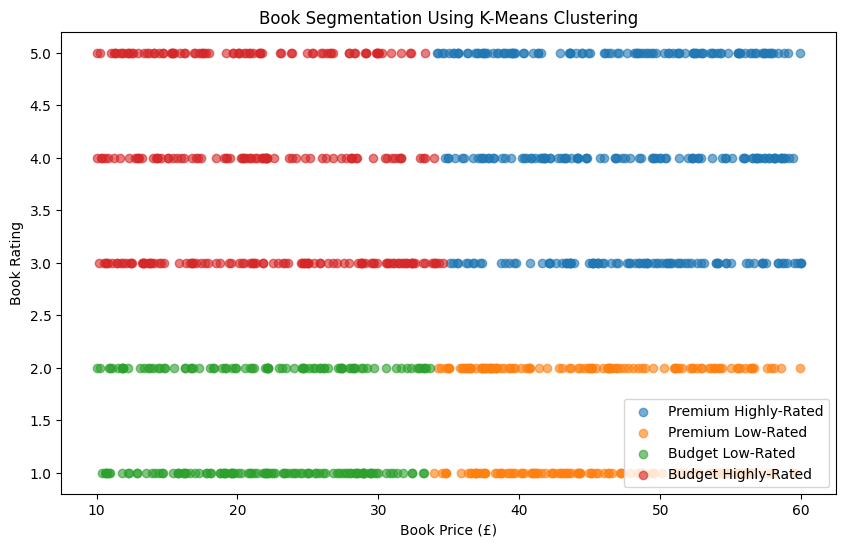

In [21]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster]
    
    plt.scatter(
        cluster_data["price_clean"],
        cluster_data["rating_numeric"],
        label=cluster_names[cluster],
        alpha=0.6
    )

plt.title("Book Segmentation Using K-Means Clustering")
plt.xlabel("Book Price (£)")
plt.ylabel("Book Rating")
plt.legend()
plt.show()

In [22]:
df.to_csv("books_clustered.csv", index=False)